In [2]:
import pandas as pd
import json

with open("raw/lluvia.json") as f:
    data = json.load(f)

df = pd.DataFrame(data)
df.head()


,id,rha,anio,numero,capnamo,almacenamiento
0,1,Península de Baja California,1995,3.0,120.5,109.4
1,2,Península de Baja California,1996,3.0,120.5,45.0
2,3,Península de Baja California,1997,3.0,120.5,28.8
3,4,Península de Baja California,1998,3.0,120.5,111.7
4,5,Península de Baja California,1999,3.0,120.5,39.3


In [3]:
df["pct_llenado"] = 100 * df["almacenamiento"] / df["capnamo"]


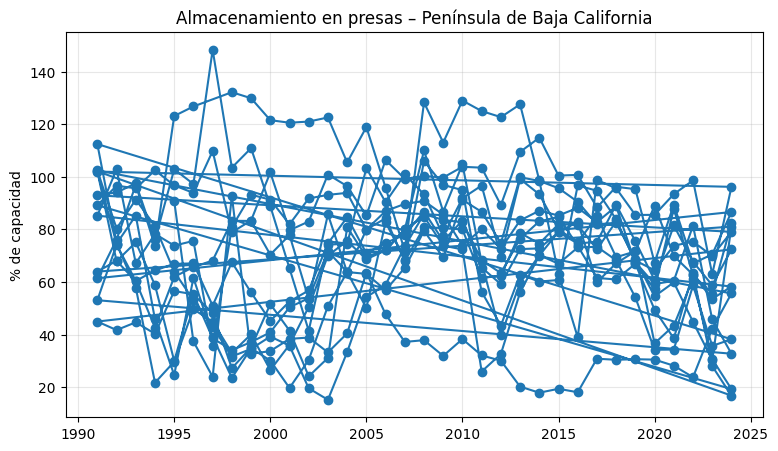

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.plot(df["anio"], df["pct_llenado"], marker="o")

plt.ylabel("% de capacidad")
plt.xlabel("")
plt.title("Almacenamiento en presas – Península de Baja California")

plt.grid(alpha=0.3)
plt.show()


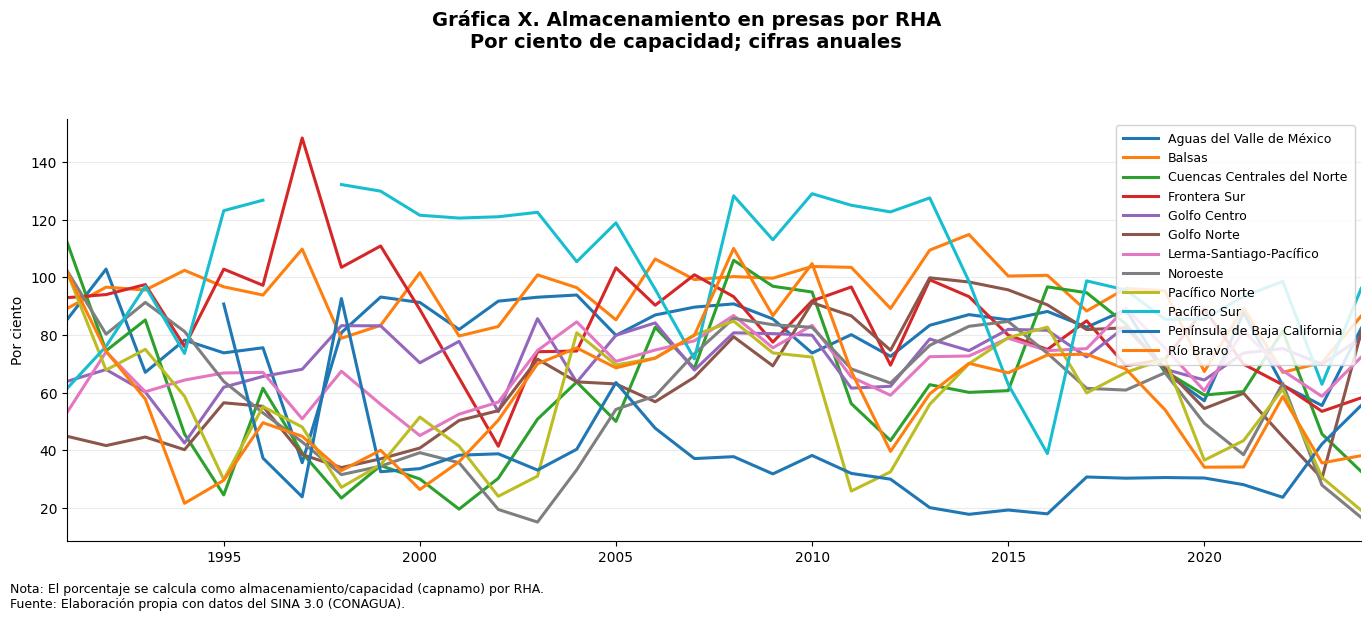

In [8]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
JSON_PATH   = "raw/presas.json"   # <- cambia a tu ruta
START_YEAR  = None                  # <- opcional (o None)
END_YEAR    = None                   # <- opcional (o None)

# formato tipo Banxico
TITLE_MAIN  = "Gráfica X. Almacenamiento en presas por RHA"
TITLE_SUB   = "Por ciento de capacidad; cifras anuales"
FOOTNOTE_1  = "Nota: El porcentaje se calcula como almacenamiento/capacidad (capnamo) por RHA."
FOOTNOTE_2  = "Fuente: Elaboración propia con datos del SINA 3.0 (CONAGUA)."

# ============================================================
# 1) CARGA JSON
# ============================================================
with open(JSON_PATH) as f:
    data = json.load(f)

# Si el JSON viniera anidado (ej. {"data":[...]}), intentamos detectarlo
if isinstance(data, dict):
    # intenta llaves típicas
    for k in ["data", "results", "result", "items"]:
        if k in data and isinstance(data[k], list):
            data = data[k]
            break

df = pd.DataFrame(data).copy()

# ============================================================
# 2) LIMPIEZA / VALIDACIÓN
# ============================================================
needed = {"rha", "anio", "almacenamiento", "capnamo"}
missing = needed - set(df.columns)
if missing:
    raise ValueError(f"Faltan columnas en el JSON: {missing}. Columnas disponibles: {list(df.columns)}")

df["anio"] = pd.to_numeric(df["anio"], errors="coerce").astype("Int64")
df["almacenamiento"] = pd.to_numeric(df["almacenamiento"], errors="coerce")
df["capnamo"] = pd.to_numeric(df["capnamo"], errors="coerce")

df = df.dropna(subset=["rha", "anio", "almacenamiento", "capnamo"]).copy()

# Porcentaje de llenado
df["pct_llenado"] = 100 * df["almacenamiento"] / df["capnamo"]

# Filtros opcionales por año
if START_YEAR is not None:
    df = df[df["anio"] >= START_YEAR]
if END_YEAR is not None:
    df = df[df["anio"] <= END_YEAR]

# ordenar
df = df.sort_values(["rha", "anio"]).reset_index(drop=True)

# ============================================================
# 3) PIVOT PARA GRAFICAR (una columna por RHA)
# ============================================================
wide = df.pivot_table(index="anio", columns="rha", values="pct_llenado", aggfunc="mean")
wide = wide.sort_index()

# ============================================================
# 4) PLOT (una línea por RHA con color distinto)
# ============================================================
fig, ax = plt.subplots(figsize=(13.8, 6.2))

# Estética: limpia y similar a reporte
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", alpha=0.25)
ax.grid(False, axis="x")

# Plot líneas (matplotlib asigna colores distintos automáticamente)
for col in wide.columns:
    ax.plot(wide.index, wide[col], lw=2.2, label=col)

# Ejes
ax.set_ylabel("Por ciento")
ax.set_xlabel("")
ax.set_xlim(wide.index.min(), wide.index.max())

# Títulos (dos líneas)
fig.suptitle(f"{TITLE_MAIN}\n{TITLE_SUB}", y=0.98, fontsize=14, fontweight="bold")

# Leyenda dentro del panel, caja semitransparente (tipo Banxico)
leg = ax.legend(
    loc="upper right",
    frameon=True,
    fontsize=9,
    ncol=1,
    borderpad=0.6,
    labelspacing=0.5,
    handlelength=2.8,
)
leg.get_frame().set_alpha(0.85)

# Nota al pie centrada
fig.text(
    0.01, 0.01,
    f"{FOOTNOTE_1}\n{FOOTNOTE_2}",
    ha="left", va="bottom", fontsize=9
)

plt.tight_layout(rect=[0, 0.06, 1, 0.92])
plt.show()


In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ============================================================
# CONFIG
# ============================================================
PATH_EXCEL = "raw/MunicipiosSequia.xlsx"
PATH_SHP   = "raw/municipios_shp/mun_2020.shp"

DATES = {
    "Enero 2024": "31-Jan-24",
    "Enero 2025": "31-Jan-25",
    "Enero 2026": "31-Jan-26",
}

# Paleta tipo Monitor de Sequía
COLORS = {
    "D0": "#fff176",   # amarillo
    "D1": "#f6c344",
    "D2": "#f39c12",
    "D3": "#d32f2f",
    "D4": "#7b1f1f",
    "Sin sequía": "#ffffff",
}

ORDER = ["Sin sequía", "D0", "D1", "D2", "D3", "D4"]

# ============================================================
# 1) LEER EXCEL
# ============================================================
df = pd.read_excel(PATH_EXCEL, sheet_name="MUNICIPIOS")

# Detectar columnas fecha dinámicamente
date_cols = [c for c in df.columns if "-" in str(c)]
df_long = df.melt(
    id_vars=["CVE_CONCATENADA"],
    value_vars=date_cols,
    var_name="fecha",
    value_name="cat"
)

df_long["fecha"] = pd.to_datetime(df_long["fecha"], errors="coerce")
df_long["cat"] = df_long["cat"].fillna("Sin sequía")

# ============================================================
# 2) FILTRAR ENERO 24–26
# ============================================================
target = {
    k: pd.to_datetime(v) for k, v in DATES.items()
}

dfs = {}
for label, d in target.items():
    tmp = df_long[df_long["fecha"] == d].copy()
    dfs[label] = tmp

# ============================================================
# 3) SHAPEFILE MUNICIPAL
# ============================================================
gdf_mun = gpd.read_file(PATH_SHP)

gdf_mun["CVE_CONCATENADA"] = (
    gdf_mun["CVE_ENT"].astype(str).str.zfill(2) +
    gdf_mun["CVE_MUN"].astype(str).str.zfill(3)
)

# ============================================================
# 4) FUNCIÓN PARA MAPEAR
# ============================================================
def make_map(ax, gdf, title):
    gdf.plot(
        column="cat",
        ax=ax,
        categorical=True,
        legend=False,
        cmap=None,
        color=gdf["cat"].map(COLORS),
        linewidth=0.1,
        edgecolor="gray"
    )
    ax.set_title(title, fontsize=12)
    ax.axis("off")

# ============================================================
# 5) FIGURA CON 3 MAPAS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

merged = {}

for ax, (label, df_t) in zip(axes, dfs.items()):
    g = gdf_mun.merge(
        df_t[["CVE_CONCATENADA", "cat"]],
        on="CVE_CONCATENADA",
        how="left"
    )
    g["cat"] = g["cat"].fillna("Sin sequía")
    make_map(ax, g, label)

# ============================================================
# 6) LEYENDA ÚNICA ABAJO
# ============================================================
handles = [
    Patch(facecolor=COLORS[k], edgecolor="black", label=k)
    for k in ORDER
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=6,
    frameon=False,
    fontsize=10
)

# ============================================================
# 7) TITULO + FUENTE
# ============================================================
fig.suptitle(
    "Conjunto de mapas. Condiciones de sequía municipal en México",
    fontsize=15,
    y=0.95
)

fig.text(
    0.5, 0.03,
    "Fuente: Elaboración propia con datos del Monitor de Sequía en México (SMN–CONAGUA).",
    ha="center",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.08, 1, 0.92])
plt.show()


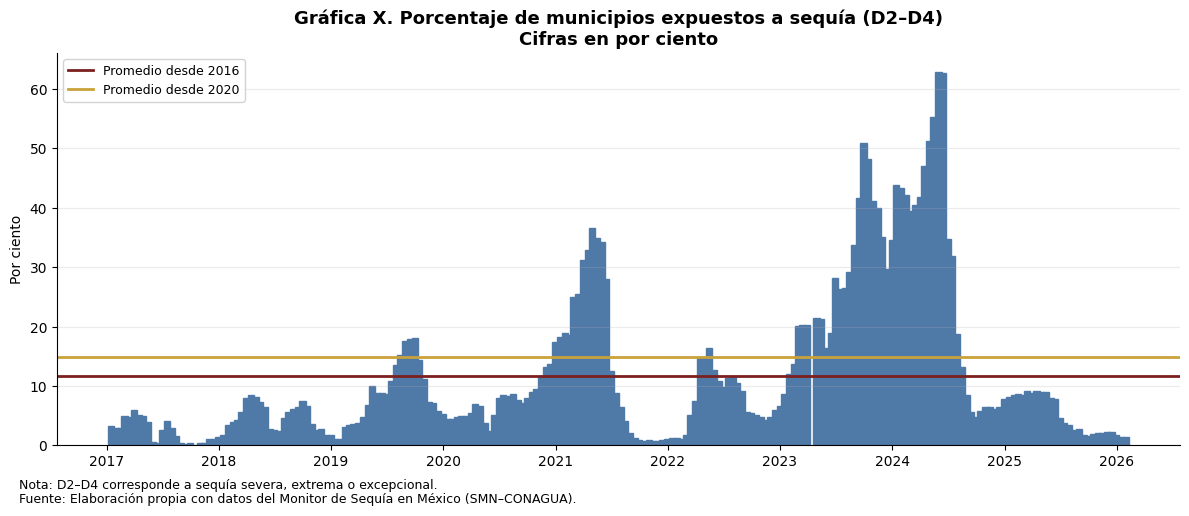

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
PATH_EXCEL = "raw/MunicipiosSequia.xlsx"
SHEET_NAME = "MUNICIPIOS"

START_DATE = "2017-01-01"   # para que se parezca al rango del ejemplo
AVG_FROM_2016 = "2016-01-01"
AVG_FROM_2020 = "2020-01-01"

# colores tipo Banxico
BAR_COLOR = "#4f79a7"
LINE_2016 = "#7b1f1f"   # vino
LINE_2020 = "#caa23a"   # dorado

SEVERE_SET = {"D2", "D3", "D4"}  # severa/extrema/excepcional

# =========================
# 1) LEER Y PASAR A LONG
# =========================
df = pd.read_excel(PATH_EXCEL, sheet_name=SHEET_NAME)

# columnas fecha (tu excel trae columnas como 15-Oct-25, 31-Jan-26, etc.)
date_cols = [c for c in df.columns if "-" in str(c)]
if not date_cols:
    raise ValueError("No encontré columnas de fecha. Revisa los nombres de columnas del Excel.")

df_long = df.melt(
    id_vars=["CVE_CONCATENADA"],
    value_vars=date_cols,
    var_name="fecha",
    value_name="cat"
)

df_long["fecha"] = pd.to_datetime(df_long["fecha"], errors="coerce")
df_long["cat"] = df_long["cat"].fillna("Sin sequía").astype(str).str.strip()

df_long = df_long.dropna(subset=["fecha"]).copy()
df_long = df_long[df_long["fecha"] >= pd.to_datetime(START_DATE)].copy()

# =========================
# 2) % municipios en D2–D4
# =========================
df_long["sev"] = df_long["cat"].isin(SEVERE_SET).astype(int)

ts = (
    df_long.groupby("fecha")["sev"]
    .mean()
    .mul(100)
    .reset_index(name="pct_municipios_severos")
    .sort_values("fecha")
)

# =========================
# 3) promedios horizontales
# =========================
avg2016 = ts.loc[ts["fecha"] >= pd.to_datetime(AVG_FROM_2016), "pct_municipios_severos"].mean()
avg2020 = ts.loc[ts["fecha"] >= pd.to_datetime(AVG_FROM_2020), "pct_municipios_severos"].mean()

# =========================
# 4) PLOT estilo Banxico
# =========================
fig, ax = plt.subplots(figsize=(12, 5.5))

ax.bar(ts["fecha"], ts["pct_municipios_severos"], width=20, color=BAR_COLOR, edgecolor=BAR_COLOR)

ax.axhline(avg2016, color=LINE_2016, lw=2, label="Promedio desde 2016")
ax.axhline(avg2020, color=LINE_2020, lw=2, label="Promedio desde 2020")

ax.set_title("Gráfica X. Porcentaje de municipios expuestos a sequía (D2–D4)\nCifras en por ciento",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Por ciento")
ax.set_xlabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25)

# leyenda
leg = ax.legend(loc="upper left", frameon=True, fontsize=9)
leg.get_frame().set_alpha(0.85)

# nota al pie
fig.text(
    0.02, 0.02,
    "Nota: D2–D4 corresponde a sequía severa, extrema o excepcional.\n"
    "Fuente: Elaboración propia con datos del Monitor de Sequía en México (SMN–CONAGUA).",
    ha="left", va="bottom", fontsize=9
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()


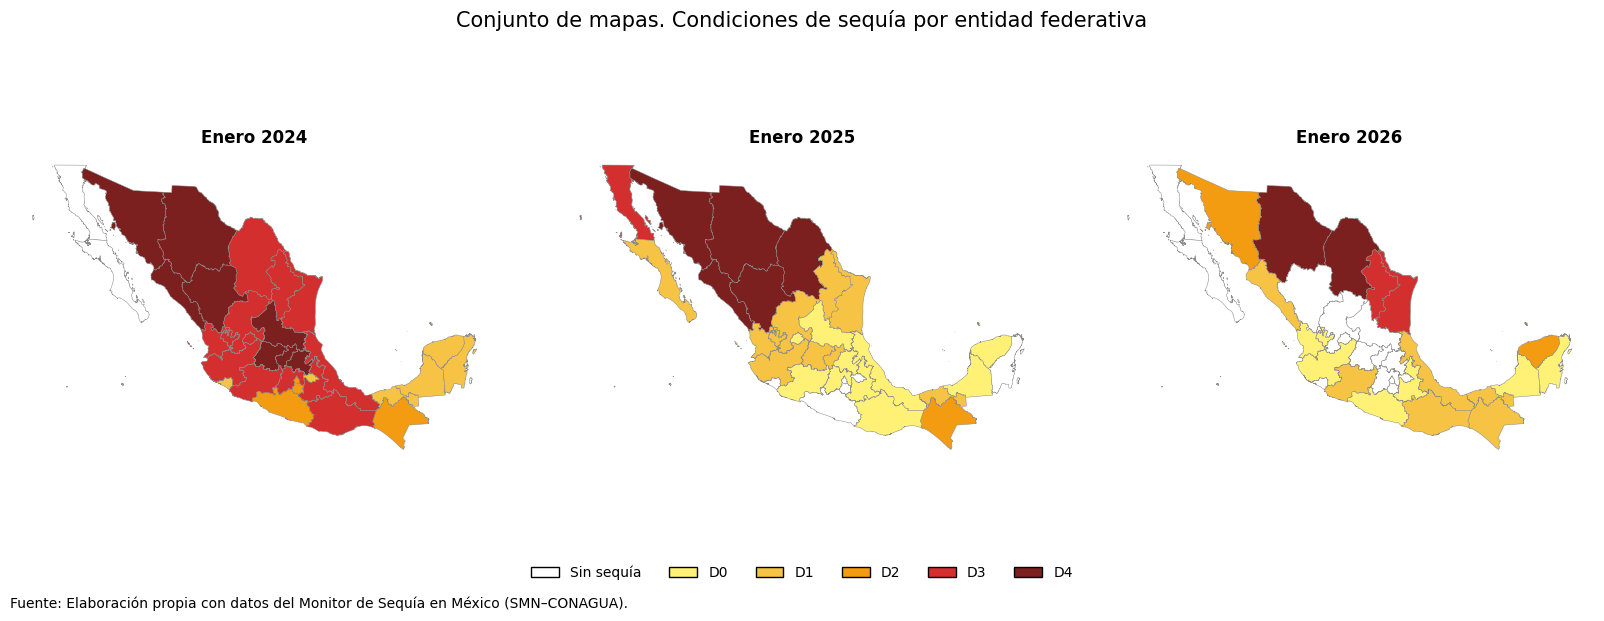

In [15]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ============================================================
# CONFIG
# ============================================================
PATH_EXCEL = "raw/MunicipiosSequia.xlsx"
SHEET_NAME = "MUNICIPIOS"
PATH_SHP   = "raw/estados_shp/estados.shp"

DATES = {
    "Enero 2024": "31-Jan-24",
    "Enero 2025": "31-Jan-25",
    "Enero 2026": "31-Jan-26",
}

# Paleta tipo Monitor de Sequía
COLORS = {
    "D0": "#fff176",
    "D1": "#f6c344",
    "D2": "#f39c12",
    "D3": "#d32f2f",
    "D4": "#7b1f1f",
    "Sin sequía": "#ffffff",
}

# Orden de severidad (para "si hay al menos un municipio, colorea el estado")
SEVERITY_ORDER = ["Sin sequía", "D0", "D1", "D2", "D3", "D4"]
SEV_RANK = {k: i for i, k in enumerate(SEVERITY_ORDER)}

# ============================================================
# 1) LEER EXCEL (municipios)
# ============================================================
df = pd.read_excel(PATH_EXCEL, sheet_name=SHEET_NAME)

# CVE_ENT en formato '01'..'32'
df["CVE_ENT"] = pd.to_numeric(df["CVE_ENT"], errors="coerce").astype("Int64")
df = df.dropna(subset=["CVE_ENT"]).copy()
df["CVE_ENT"] = df["CVE_ENT"].astype(int).astype(str).str.zfill(2)

# columnas fecha tipo '31-Jan-26'
date_cols = [c for c in df.columns if "-" in str(c)]
if not date_cols:
    raise ValueError("No encontré columnas de fecha (con '-') en el Excel.")

df_long = df.melt(
    id_vars=["CVE_ENT"],
    value_vars=date_cols,
    var_name="fecha",
    value_name="cat"
)

df_long["fecha"] = pd.to_datetime(df_long["fecha"], errors="coerce")
df_long = df_long.dropna(subset=["fecha"]).copy()

df_long["cat"] = df_long["cat"].fillna("Sin sequía").astype(str).str.strip()
# normaliza posibles vacíos raros
df_long.loc[df_long["cat"].isin(["", "nan", "None"]), "cat"] = "Sin sequía"

# ============================================================
# 2) FILTRAR 3 FECHAS (si no existe exacta, usa mes-año)
# ============================================================
target = {k: pd.to_datetime(v) for k, v in DATES.items()}

dfs = {}
for label, d in target.items():
    tmp = df_long[df_long["fecha"] == d].copy()
    if tmp.empty:
        tmp = df_long[(df_long["fecha"].dt.year == d.year) & (df_long["fecha"].dt.month == d.month)].copy()
    dfs[label] = tmp

# ============================================================
# 3) AGREGAR A NIVEL ESTADO:
#    "si al menos un municipio tiene D0–D4, colorea el estado"
#    => tomamos la máxima severidad observada (D4 > ... > D0 > Sin sequía)
# ============================================================
def max_severidad(x: pd.Series) -> str:
    # mapea a ranks y toma el máximo
    ranks = x.map(lambda v: SEV_RANK.get(v, 0))
    return SEVERITY_ORDER[int(ranks.max())]

state_maps = {}
for label, dfi in dfs.items():
    g = (
        dfi.groupby("CVE_ENT")["cat"]
        .apply(max_severidad)
        .reset_index()
    )
    state_maps[label] = g

# ============================================================
# 4) LEER SHAPEFILE ESTADOS
# ============================================================
gdf_states = gpd.read_file(PATH_SHP)

if "CVE_ENT" not in gdf_states.columns:
    raise ValueError(f"Tu shapefile no trae 'CVE_ENT'. Columnas: {list(gdf_states.columns)}")

gdf_states["CVE_ENT"] = pd.to_numeric(gdf_states["CVE_ENT"], errors="coerce").astype("Int64")
gdf_states = gdf_states.dropna(subset=["CVE_ENT"]).copy()
gdf_states["CVE_ENT"] = gdf_states["CVE_ENT"].astype(int).astype(str).str.zfill(2)

# ============================================================
# 5) PLOT HELPERS
# ============================================================
def plot_map(ax, gdf, title):
    gdf.plot(
        ax=ax,
        color=gdf["cat"].map(COLORS),
        linewidth=0.35,
        edgecolor="#8a8a8a"
    )
    ax.set_title(title, fontsize=12, fontweight="bold", pad=6)
    ax.axis("off")

# ============================================================
# 6) FIGURA COMPACTA (menos espacio blanco)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16.5, 6.2))

for ax, (label, tab) in zip(axes, state_maps.items()):
    m = gdf_states.merge(tab, on="CVE_ENT", how="left")
    m["cat"] = m["cat"].fillna("Sin sequía")
    plot_map(ax, m, label)

# Leyenda única abajo (pegada)
handles = [Patch(facecolor=COLORS[k], edgecolor="black", label=k) for k in SEVERITY_ORDER]
fig.legend(
    handles=handles,
    loc="lower center",
    ncol=6,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 0.04)  # sube la leyenda
)

# Título + fuente (más compacto)
fig.suptitle(
    "Conjunto de mapas. Condiciones de sequía por entidad federativa",
    fontsize=15,
    y=0.98
)

fig.text(
    0.02, 0.015,
    "Fuente: Elaboración propia con datos del Monitor de Sequía en México (SMN–CONAGUA).",
    ha="left",
    fontsize=10
)

# Ajustes finos para quitar blanco
plt.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.10, wspace=0.12)
plt.show()
